In [156]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [157]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass
     

In [158]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [159]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [160]:
class GridProblem(Problem):
    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self):
        return self.start

    def is_goal(self, state):
        # TODO 1
        return state == self.goal

    def in_bounds(self, state):
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state):
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state):
        # TODO 2
        legal_actions = []
        row, col = state

        for action, (dr, dc) in MOVES.items():
            new_state = (row + dr, col + dc)

            if self.in_bounds(new_state) and self.is_free(new_state):
                legal_actions.append(action)

        return legal_actions

    def result(self, state, action):
        # TODO 3
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(self, state, action, next_state):
        # TODO 4
        return 1

class SearchAlgorithm(ABC):

    def expand(self, problem: Problem, node: Node):
        # TODO 5
        s = node.state

        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)

            yield Node(
                state=s_prime,
                parent=node,
                action=action,
                path_cost=cost
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [161]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [164]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # Return the cost of moving from state to next_state.
        # Entering a cell costs that cell's terrain cost.
        row, col = next_state  # Unpack the destination cell
        return self.terrain_costs[row][col]

In [165]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [166]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3: Return the straight-line distance between state and goal.
    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1 - r2)**2 + (c1 - c2)**2)

def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided"""
    return 0.0

In [167]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [168]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [169]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        # Estimate distance from current node to goal
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        # To be defined by specific search strategies (A*, Greedy, etc.)
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem):

        # Start from the initial state
        initial_state = problem.initial_state()
        initial_node = Node(state=initial_state)

        # Priority queue keeps nodes ordered by f(n)
        frontier = PriorityQueue()
        frontier.push(self.evaluation(initial_node, problem), initial_node)

        # Track best-known path to each state
        reached = {initial_state: initial_node}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:

            # Always expand the lowest f-cost node
            node = frontier.pop()

            # Goal test happens when node is actually selected
            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached),
                    limit=None,
                    iterations=None
                )

            nodes_expanded += 1

            # Explore neighbors
            for child in self.expand(problem, node):
                s = child.state

                # Keep only the best (cheapest) path to each state
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    frontier.push(self.evaluation(child, problem), child)

            # Track memory usage of frontier
            max_frontier_size = max(max_frontier_size, len(frontier))

        # If no solution is found
        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
            limit=None,
            iterations=None
        )

In [170]:
# GreedyBestFirstSearch(BestFirstSearch):
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # Greedy choice: only care about estimated distance to goal
        return self.h(node, problem)

In [171]:
# AStarSearch(BestFirstSearch)
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # A* balances cost so far (g) with estimated cost to goal (h)
        return node.path_cost + self.h(node, problem)

In [172]:
# UniformCostSearch(BestFirstSearch):
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        # Only care about path cost so far (no heuristic)
        return node.path_cost

In [173]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # Weighted A*: slightly "over-trusts" the heuristic for faster search
        return node.path_cost + self.weight * self.h(node, problem)

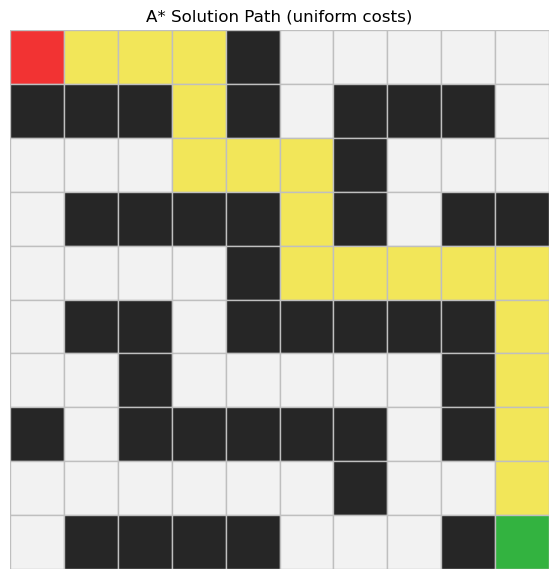

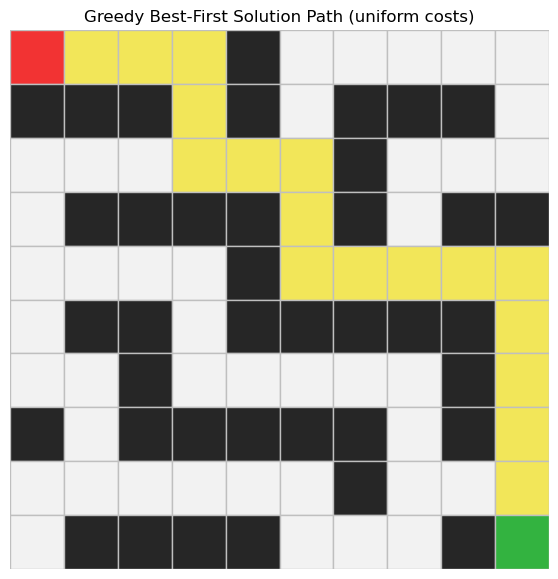

In [174]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)
     

# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

In [175]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)
     

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


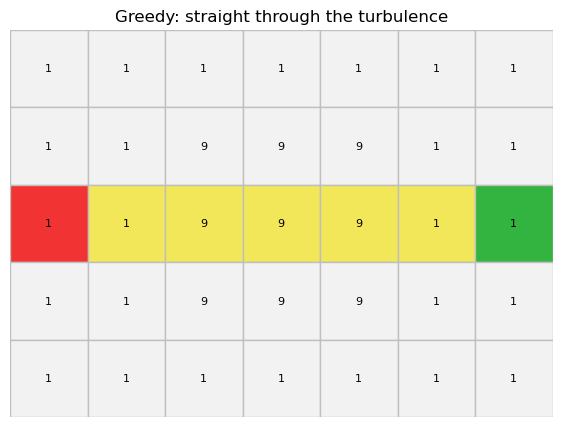

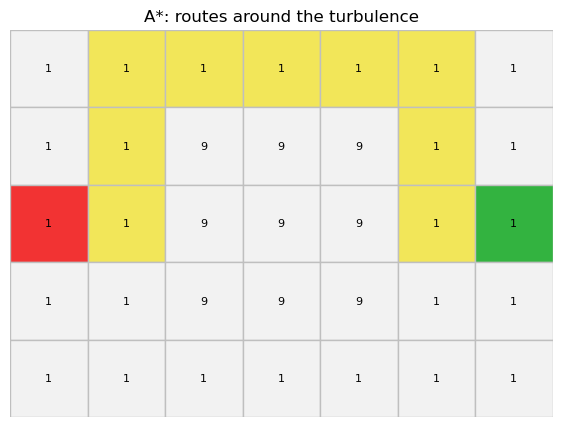

In [176]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)
     

The two solution costs were 12 for Greedy Best-First Search and 10 for A*. Greedy expanded fewer nodes than A* on this map because it followed the straight path directly through the high-cost turbulence band, while A* explored additional states to confirm that the cheaper detour existed.

However, “Greedy expanded fewer nodes” does not mean it is better because it ignores path cost g(n) and can therefore return a more expensive, suboptimal solution. A*, on the other hand, may expand more nodes but guarantees the lowest-cost path, making it the better algorithm when solution quality matters.

In [141]:
def inflated_heuristic(factor: float):
    def h(state, goal):
        return factor * manhattan_distance(state, goal)
    return h

# Once TODO 8 is complete, run the comparison.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


The inflated heuristic returned a suboptimal path on the mild turbulence map, where the direct route through the cost-3 band is chosen instead of the cheaper detour. This resulted in a higher total path cost (e.g., 12 instead of the optimal 10, so it is worse by 2 cost units).

It also expanded fewer nodes than standard A* in both the uniform and mild maps, because the larger heuristic values make the search more “directed” and reduce exploration of alternative paths.

As a drone engineer, I would deliberately accept an inadmissible heuristic when fast decision-making is more important than optimality, such as real-time navigation in dynamic or time-critical environments where a slightly more expensive path is acceptable if it is found significantly faster

In [142]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200):

        start = problem.initial_state()

        # heuristic helper: h(n)
        def h(state):
            return self.heuristic(state, problem.goal)

        # depth-first search with an f-cost limit
        def dfs(node, g, limit, path):

            # f(n) = g(n) + h(n)
            f = g + h(node.state)

            # cut off if we exceed current limit
            if f > limit:
                return None, f

            # goal found within current bound
            if problem.is_goal(node.state):
                return node, f

            min_over = float("inf")  # next best limit candidate

            # explore children (DFS style)
            for child in self.expand(problem, node):

                # avoid cycles in current path
                if child.state in path:
                    continue

                result, new_limit = dfs(
                    child,
                    child.path_cost,
                    limit,
                    path | {child.state}  # extend path
                )

                # if goal found, bubble it up immediately
                if result:
                    return result, new_limit

                # track smallest f-value that exceeded limit
                min_over = min(min_over, new_limit)

            return None, min_over

        # root node (start of search)
        root = Node(state=start, path_cost=0)

        # initial limit = heuristic of start state
        limit = h(start)

        # iterative deepening loop
        for _ in range(max_iterations):

            result, next_limit = dfs(root, 0, limit, {start})

            # success case
            if result:
                return SearchResult("IDA*", "success", result, 0, 0, 0, [])

            # no better nodes exist → failure
            if next_limit == float("inf"):
                return SearchResult("IDA*", "failure", None, 0, 0, 0, [])

            # increase limit and try again
            limit = next_limit

        # safety stop if too many iterations
        return SearchResult("IDA*", "cutoff", None, 0, 0, 0, [])

In [143]:
class IDAStarSearch(SearchAlgorithm):
    """Iterative Deepening A* - memory-efficient variant of A*."""
    
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200):

        start = problem.initial_state()

        def h(state):
            return self.heuristic(state, problem.goal)

        def dfs(node, g, limit, path):
            """Depth-first search with f-cost cutoff."""
            f = g + h(node.state)

            # Prune if this path already exceeds the current limit
            if f > limit:
                return None, f

            # Goal found within current bound
            if problem.is_goal(node.state):
                return node, f

            # Track the smallest f-value that exceeded the limit
            min_over = float("inf")

            for child in self.expand(problem, node):
                # Avoid revisiting nodes in current path (cycle detection)
                if child.state in path:
                    continue

                result, new_limit = dfs(
                    child,
                    child.path_cost,
                    limit,
                    path | {child.state}  # Add to path set
                )

                # Goal found - bubble it up immediately
                if result:
                    return result, new_limit

                min_over = min(min_over, new_limit)

            return None, min_over

        # Start the search
        root = Node(state=start, path_cost=0)
        limit = h(start)  # Initial f-limit is the heuristic of the start state

        # Iteratively deepen the f-cost bound
        for _ in range(max_iterations):
            result, next_limit = dfs(root, 0, limit, {start})

            if result:
                return SearchResult("IDA*", "success", result, 0, 0, 0, [])

            # No more nodes to explore - search failed
            if next_limit == float("inf"):
                return SearchResult("IDA*", "failure", None, 0, 0, 0, [])

            # Increase the limit to the next best f-cost and try again
            limit = next_limit

        # Safety cutoff if we exceed max iterations
        return SearchResult("IDA*", "cutoff", None, 0, 0, 0, [])

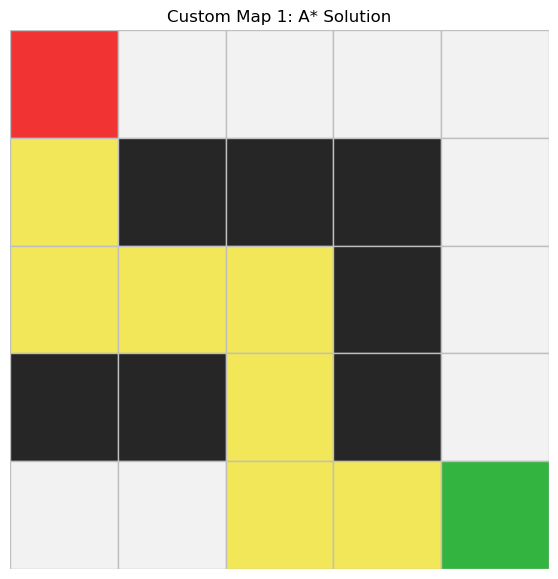

In [144]:
custom_grid_1 = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0],
    [1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0],
]

custom_costs_1 = None  # not needed for GridProblem

custom_start_1 = (0, 0)
custom_goal_1 = (4, 4)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

show_results(custom_results_1)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    title="Custom Map 1: A* Solution"
)

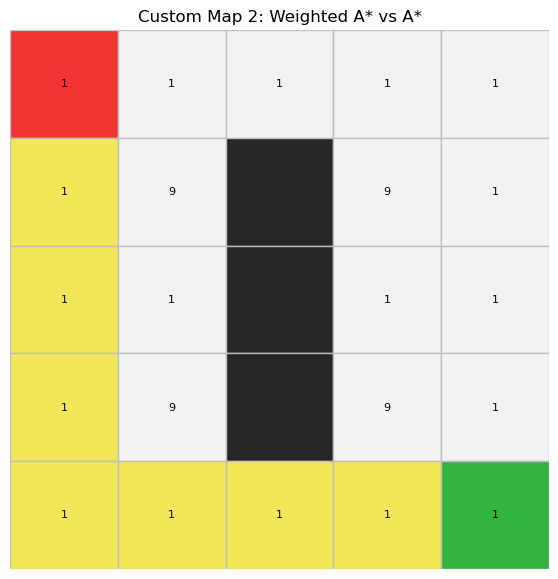

In [145]:
custom_grid_2 = [
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 1, 1],
    [1, 9, 9, 9, 1],
    [1, 1, 1, 1, 1],
    [1, 9, 9, 9, 1],
    [1, 1, 1, 1, 1],
]

custom_start_2 = (0, 0)
custom_goal_2 = (4, 4)

custom_problem_2 = WeightedGridProblem(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    terrain_costs=custom_costs_2
)

custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]

show_results(custom_results_2)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[2].path,
    terrain_costs=custom_costs_2,
    title="Custom Map 2: Weighted A* vs A*"
)

16.1 Heuristic Functions
1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?
   h(n) represents the cost to the point from n until the goal has been reached. In this lab, h(n) is calculated based on geometric data obtained from the grid (e.g. using Manhattan or Euclidean distance to determine how far the point is away from the goal).
2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?
   The relaxation removes obstacles and terrain costs from the problem domain, thus allowing for free movement between points (essentially movement can occur in straight line along grid directions
3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and  what does domination predict about nodes expanded?
   Manhattan distance tends to dominate when used with a grid that allows movement along 4 directions when compared to using Euclidean distance, and therefore tends to expand fewer nodes in the search space than Euclidean distance does in this type of grid
4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?
   Keeping step cost consistent with grid distance when calculating step costs ensures that Manhattan does not overestimate when costs are < 1 (such as for example step costs that are 0.5, etc.) and render them inadmissible.

16.2 Greedy Best-First Search
1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?
   It ignores the path cost g(n) and uses only h(n). This leads to Greedy taking risky paths through high-cost terrains.
2. Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?
   Fewer nodes expanded does not guarantee either an optimal solution or even a good solution - Greedy can choose to take expensive paths
3. Describe a drone mission where Greedy's behaviour would actually be acceptable.
    Greedy is acceptable when speed is more important than optimality - for example: Quickly navigating (to an unknown destination) or when one needs some approximate real-time guidance.

16.3 A* Search
1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.
The total estimated cost = cost to date + estimated future costs.
2. Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?
   There may be a better (cheaper) path still in the frontier so we may have a non-optimal solution depending on when we stop searching.
   
3. Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?
   We need to track the best-known cost for every state that has been expanded, and a set cannot keep track of paths that are better than others.
4. Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?
   UCS vs. A* "gap": A* will typically expand fewer nodes because it is using the heuristic to direct its search toward the goal.

16.4 Admissibility and Consistency
1. State the definitions of admissible and consistent. Which implies which?
   The admissible heuristic never over-estimates, and the consistent heuristic meets triangle inequality and implies that they are admissible.
2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?
   The experiment showed that heuristics that are in-admissible can reduce the number of nodes expanded, but may violate optimality
3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.
   The Manhattan heuristic is indeed consistent, as every move increases cost by at least 1, which meets the triangle inequality.

16.5 Weighted A* and Trade-offs
1. How does the weight W interpolate between UCS, A*, and Greedy?
   W = 0 → UCS, W = 1 → A*, W > 1 → more greedy behavior
2. What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?
    Solution cost ≤ W × optimal cost.
   
3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?
   A* with W ≈ 2 for good balance between speed and near-optimal paths.

16.6 Memory and Real-World Drone Context
1. Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?
   Frontier + reached store many nodes. IDA* avoids this using DFS with iterative limits but re-expands nodes.
2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?
   Weather, wind, no-fly zones, battery levels, time-varying risk
3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?
   Heuristics break; requires real-time or dynamic planning methods.
4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?
   A* or Weighted A* (W ≈ 2), depending on time constraints and need for optimality.